In [2]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")
from transformers import pipeline
import nltk
import pandas as pd
from collections import Counter
from tqdm import tqdm

nltk.download('punkt')

# Load the data
data = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\final_data_cleaned_with_author_names.csv")
data.replace('\n', pd.NA, inplace=True)

# Drop rows containing NaN values
#data.dropna(inplace=True)

# Reset index if needed
data.reset_index(drop=True, inplace=True)
print(len(data["text"]))

class zero_shot_voting():
    def __init__(self):
        # Initializing models for zero-shot sentiment classification
        self.models = [
            #'DTAI-KULeuven/robbert-v2-dutch-sentiment',  # Label Negative Positive
            #'DTAI-KULeuven/robbertje-merged-dutch-sentiment', # Negative or Positive
            'nlptown/bert-base-multilingual-uncased-sentiment', # Other models can be added
            "clips/republic",
            #"tabularisai/multilingual-sentiment-analysis"
            "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned"
        ]
        self.classifiers = [pipeline(task="sentiment-analysis", model=model, return_all_scores=True, truncation=True, max_length=512) for model in self.models]

    def sentiment(self, prediction):
        # Converting all predictions into numerical format for consistency
        if(prediction=="Very Positive" or prediction=="Positive" or prediction == "LABEL_1" or prediction== '1' or prediction=="pos" or prediction=="4 stars" or prediction=="5 stars" or prediction=="positive"):
            return int(1)
        elif(prediction=="Very Negative" or prediction=="Negative" or prediction == "LABEL_0" or prediction=='-1' or prediction=="neg" or prediction=="1 star" or prediction=="negative" or prediction=="2 stars"):
            return int(-1)
        else:
            return int(0)

    def prediction(self, text):
        # Prediction from all models
        predictions = []
        prediction_scores = []
        for classifier in self.classifiers:
            result = classifier(text)[0]
            

            if(len(result) == 2):
                # Extract scores for positive and negative labels
                positive_score = result[1]['score']
                negative_score = result[0]['score']

                # Determine sentiment label based on scores
                if abs(positive_score - negative_score) <= 0.1:
                    sentiment_label = 'neutral'
                elif positive_score > negative_score:
                    sentiment_label = 'Positive'
                else:
                    sentiment_label = 'Negative'


                predictions.append(self.sentiment(sentiment_label))

            else:
                predictions.append(self.sentiment(max(result, key=lambda x: x['score'])['label']))
                prediction_scores.append(max(result, key=lambda x: x['score'])['score'])
        return predictions, prediction_scores

    def are_all_same(self, pred):
        return all(x == pred[0] for x in pred)

    def overall_sentiment_sentence(self, predictions):
        """
        Returns overall sentiment based on strict majority voting.
        If a label appears 2 or more times among model predictions, return that label.
        Else, return 0 (Neutral).
        """
        label_counts = Counter(predictions)

        for label, count in label_counts.items():
            if count >= 2:
                return label  # Strong majority found

        return 0  # Neutral if no label appears 2 or more times


    def sentiment_over_comment_majority(self, sentiment):
        if not sentiment:
            return 0  # Default to neutral if no sentiments

        counts = Counter(sentiment)
        most_common = max(counts.values(), default=0)  # Use default to avoid empty sequence error
        max_labels = [label for label, count in counts.items() if count == most_common]

        if len(max_labels) == 1:
            return max_labels[0]

        elif len(max_labels) == 2 and counts[max_labels[0]] == counts[max_labels[1]]:
            return 0  # Mixed sentiment case

        return 2  # Neutral for other ambiguous cases

    def sentiment_across_sentences(self, text):
        sentences = nltk.sent_tokenize(text, language='dutch')
        majority_voting_sentences = []
        overall_sentiment = []
        overall_sentiment_score = []
        for sentence in sentences:
            overall_sentiment1, overall_sentiment_score1 = self.prediction(sentence)
            overall_sentiment.append(overall_sentiment1)
            overall_sentiment_score.append(overall_sentiment_score1)
            majority_score = self.overall_sentiment_sentence(overall_sentiment1)
            majority_voting_sentences.append(majority_score)
        sentiment_over_comment = self.sentiment_over_comment_majority(majority_voting_sentences)
        return overall_sentiment, overall_sentiment_score, majority_voting_sentences, sentiment_over_comment


# DataFrame to store results
df = pd.DataFrame(columns=["Comment", "Sentiment of the four models", "Score", "Overall voted sentiment", "Overall Sentiment over comment from sentences", 
                           "Sentiment from models", "Sentiment from models score", "Sentiment over comment from models", "Score for entire comment"])

obj = zero_shot_voting()

# Process each comment
for i in tqdm(range(len(data["text"]))):
    overall_sentiment, overall_sentiment_score, overall_sentiment_voting, sentiment_over_comment = obj.sentiment_across_sentences(data["text"][i])
    # Sentiment over sending entire comment to models
    pred, pred_score = obj.prediction(data["text"][i])

    check = {
        'Post': data["text_ha"][i],
        'Comment': data["text"][i],
        'Author Name': data["author_name"][i],
        #"Posts_time": data["time.x"][i],
        "Comments_time": data["time"][i],
        'Sentiment of the four models': overall_sentiment,
        'Score': overall_sentiment_score,
        'Overall voted sentiment': overall_sentiment_voting,
        'Overall Sentiment over comment from sentences': sentiment_over_comment,
        "Sentiment from models": pred,
        "Sentiment from models score": pred_score,
        "Sentiment over comment from models": obj.overall_sentiment_sentence(pred),
        "Score for entire comment": pred_score
    }
    check = pd.DataFrame([check])
    df = pd.concat([df, check], ignore_index=True)

# Save results to CSV
df.to_csv("Sentiments_cleaned_comments.csv", index=False)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\20245179\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


3197


100%|██████████| 3197/3197 [52:04<00:00,  1.02it/s]  


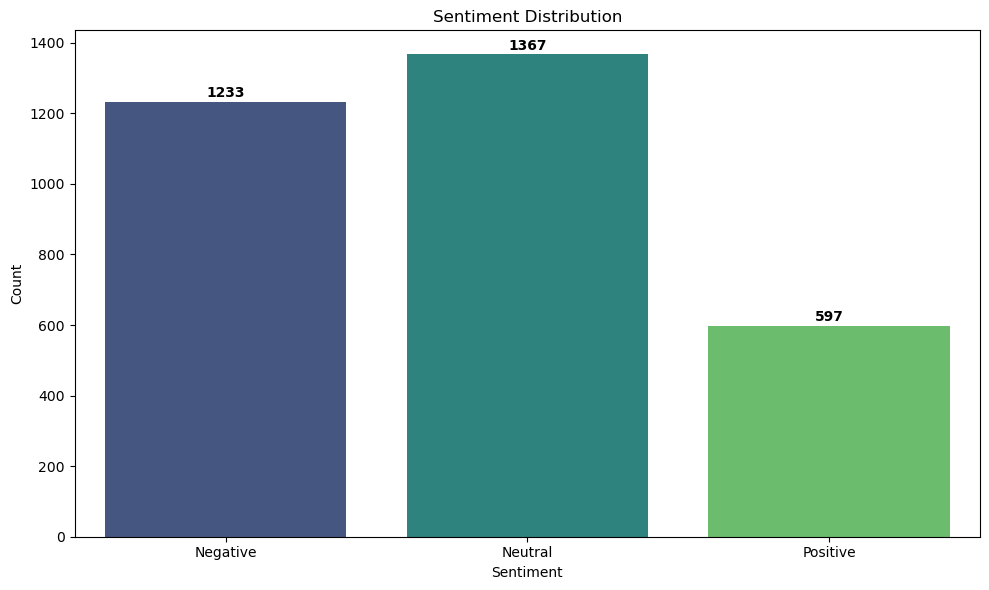

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map numeric sentiment to text labels
sentiment_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Count occurrences
sentiment_counts = df['Sentiment over comment from models'].map(sentiment_map).value_counts()

# Define desired label order
desired_order = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=desired_order, y=[sentiment_counts.get(label, 0) for label in desired_order], palette='viridis')

# Place count labels on bars
for bar, count in zip(ax.patches, [sentiment_counts.get(label, 0) for label in desired_order]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 5, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [4]:
sentiment_counts

Sentiment over comment from models
Neutral     1367
Negative    1233
Positive     597
Name: count, dtype: int64

In [ ]:
#### plot categories